#### Import/install

##### Setup

In [36]:
### CELL 11: Install Required Libraries (stable Windows/Anaconda setup)
# %load_ext autoreload
# %autoreload 2

# Use user site-packages to avoid permission/lock issues in base Anaconda folders.
%pip install --upgrade pip
%pip install --user --index-url https://download.pytorch.org/whl/cpu torch torchvision torchaudio

%pip install xlsxwriter
%pip install optuna
%pip install stable-baselines3 gymnasium sb3-contrib
%pip install seaborn

%pip install plotly
%pip install pulp
%pip install nbformat

print("After package updates, restart the kernel once before imports.")

Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://download.pytorch.org/whl/cpu
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
After package updates, restart the kernel once before imports.


In [37]:
### CELL 12: Import Libraries
import pandas as pd
import numpy as np
#import IPython.display as display
from matplotlib import pyplot as plt
import matplotlib.dates as mdates
from datetime import date, datetime
#from mpl_toolkits.mplot3d import Axes3D
#from matplotlib import cm
#import io
#import base64
# for generating random values
import random
# for copying python objects
import copy
import sys

import json
from pathlib import Path

from sklearn.linear_model import LinearRegression

from enum import Enum  #Za definicijo stvari ki jih definiram z celimi števili npr, katero akcijo bomo naredili
from datetime import datetime
import seaborn as sns
import os
import importlib

# try:
#     from google.colab import files #TYPE: ignore
#     IN_COLAB = True
# except ImportError:
#     IN_COLAB = False
IN_COLAB = os.path.exists('/content')    
IN_MAC = sys.platform == "darwin"
IN_WINDOWS = sys.platform == "win32"

import xlsxwriter

from pathlib import Path
import re

import torch as T
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
# import gym
from collections import deque

import pulp

# 1. Check for NVIDIA CUDA (Linux/Windows)
if T.cuda.is_available():
    device = T.device("cuda")
    print(f"Using NVIDIA CUDA GPU: {T.cuda.get_device_name(0)}")

# 2. Check for Apple Silicon MPS (Mac M1/M2/M3/M4)
elif T.backends.mps.is_available():
    device = T.device("mps")
    print("Using Apple Silicon MPS Acceleration")

# 3. Fallback to CPU
else:
    device = T.device("cpu")
    print("Using CPU")

# Example: Sending a tensor to the selected device
x = T.rand(3, 3, device=device)
print("\nTensor created on device:", x.device)

from matplotlib.lines import Line2D
import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances

from Tabular_RL_SARSA import (
    LinearFunctionSarsaAgent,
    QL_trening_krajsi, QL_trening_daljsi,
    State, Action,
    BatMaxPraTrenutno, BatMaxPolTrenutno,
    PaneliOdvec, BaterijaSprememba,
)

# Optional legacy helpers (kept backward-compatible if file exists)
try:
    from Normalization_Functions import normalize_dataset, ResultConverter, normalize_single_value
except ImportError:
    normalize_dataset = None
    ResultConverter = None
    normalize_single_value = None

import Environment as environment_module
importlib.reload(environment_module)
HouseholdEnvironment = environment_module.HouseholdEnvironment

from Basic_Functions import calculate_interval_price

from Ploting_Functions import plotMultiY

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from types import SimpleNamespace

Using Apple Silicon MPS Acceleration

Tensor created on device: mps:0


In [38]:
# Test 1: Check if the file exists
import os
import importlib
import sys
file_path = "Ploting_Functions.py"
print(f"File exists: {os.path.exists(file_path)}")
print(f"Current directory: {os.getcwd()}")

# Test 1b: Inspect file contents for function name
try:
    with open(file_path, "r", encoding="utf-8", errors="replace") as f:
        content = f.read()
    print(f"File length: {len(content)}")
    print(f"First 200 chars: {content[:200]!r}")
    print(f"'plotMultiY' in file: {'plotMultiY' in content}")
    for line in content.splitlines():
        if "def" in line:
            print(f"DEF LINE: {line!r}")
except Exception as e:
    print(f"Error reading file: {type(e).__name__}: {e}")

# Test 2: Import module and inspect (force reload)
try:
    if "Ploting_Functions" in sys.modules:
        del sys.modules["Ploting_Functions"]
    import Ploting_Functions as pf
    pf = importlib.reload(pf)
    print("Module imported successfully")
    print(f"Module file: {pf.__file__}")
    print(f"Has plotMultiY: {hasattr(pf, 'plotMultiY')}")
    print(f"Names containing 'plot': {[n for n in dir(pf) if 'plot' in n.lower()]}")
except Exception as e:
    print(f"Error importing module: {type(e).__name__}: {e}")
    import traceback
    traceback.print_exc()

# Test 3: Direct function import
try:
    from Ploting_Functions import plotMultiY
    print("✓ plotMultiY imported successfully")
except Exception as e:
    print(f"✗ Cannot import plotMultiY: {type(e).__name__}: {e}")
    import traceback
    traceback.print_exc()

# Test 4: Direct function access from module
try:
    _ = pf.plotMultiY
    print("✓ plotMultiY resolved from module")
except Exception as e:
    print(f"✗ Cannot access plotMultiY from module: {type(e).__name__}: {e}")
    import traceback
    traceback.print_exc()

File exists: True
Current directory: /Users/tomaz/Documents/Andraz/Household-RL
File length: 11380
First 200 chars: '### CELL 13: Function for Plotting Graphs\nimport matplotlib.pyplot as plt\nimport matplotlib.dates as mdates\nfrom datetime import date, datetime\n\n"Funkcija za risanje grafov"\ndef plotMultiY(X, Y=None, '
'plotMultiY' in file: True
DEF LINE: 'def plotMultiY(X, Y=None, X_label="X_os", Y_Label=None,'
DEF LINE: 'def plot_btr_comparison(comparison_df, metric="price_mean", title="BTR Algorithm Comparison", save=False):'
DEF LINE: 'def plot_training_progress(timestamps, rewards, prices=None, algorithm_name="BTR", title="Training Progress", save=False):'
DEF LINE: 'def plot_price_distribution(results_df, algorithm_filter=None, title="Energy Cost Distribution", save=False):'
DEF LINE: 'def plot_reward_vs_price(comparison_df, title="Reward vs Energy Cost Trade-off", save=False):'
DEF LINE: 'def plot_algorithm_ranking(comparison_df, metric="price_mean", ascending=True, title="A

##### Inport

In [39]:
#### CELL 15: Load Dataset - Adjusted to Use Relative Path for Local File

if IN_COLAB:
    from google.colab import files
    print("Running in Colab")
    VhodniPodatki = pd.read_csv("/content/Household-RL/VhodniPodatki.csv")
elif IN_WINDOWS or IN_MAC:    #Windows or MAC
    VhodniPodatki = pd.read_csv("Datasorted by user/Ausgrid 123.csv")  # Use relative path for local file ("Datasorted by user/Ausgrid 1.csv")VhodniPodatki
VhodniPodatki.index = pd.to_datetime(VhodniPodatki['Timestamp_UTC'], format='ISO8601')
VhodniPodatki = VhodniPodatki.drop(columns=['Timestamp_UTC'])
CenaMer = pd.DataFrame(VhodniPodatki["SMP"])
SoncnaMer = pd.DataFrame(VhodniPodatki["Energy_Generation"])
PorabaMer = pd.DataFrame(VhodniPodatki["Energy_Consumption"])

In [40]:
### CELL 16: Split Dataset into Training and Testing Sets
# test_size = 0.5  # test size
test_size = 1/3  # test size
train_data, test_data = train_test_split(
    VhodniPodatki,
    test_size=test_size,
    shuffle=False
)

#### Osnovne funkcije

In [41]:
### CELL 21: Define General Functions
'Definicija splosnih funkcij'

# Battery transfer limits are specified per 15-minute step.
BASE_STEP_MINUTES = 15.0
BAT_MAX_POLNJENJE_BASE = 1.5
BAT_MAX_PRAZNJENJE_BASE = 1.5

# Infer dataset resolution and adapt all per-step parameters.
step_minutes = (
    VhodniPodatki.index.to_series().sort_values().diff().dropna().dt.total_seconds().median() / 60.0
)
if not np.isfinite(step_minutes) or step_minutes <= 0:
    step_minutes = BASE_STEP_MINUTES

KorakovNaDan = int(round((24 * 60) / step_minutes))
step_scale = float(step_minutes / BASE_STEP_MINUTES)

BatMaxPolnjenje = BAT_MAX_POLNJENJE_BASE * step_scale
BatMaxPraznjenje = BAT_MAX_PRAZNJENJE_BASE * step_scale
BatKapaciteta = 20
BatUcinkovitost = 0.95
faktor_cenitve = 1

faktorN1 = 1
faktorN2 = 1
faktorN3 = 1

fc1_dims = 64
fc2_dims = 32
fc3_dims = 16

lr = 0.001
gamma = 0.99
epsilon_start = 1.0
epsilon_end = 0.01
epsilon_decay = 4e-5
batch_size = KorakovNaDan
replace_target = KorakovNaDan * 7

weight_decay = 1e-4

faktorN1 = 0
faktorN2 = 0
faktorN3 = 1
faktor_cenitve = 2/3
BatUcinkovitost = 0.95
BatKapaciteta = 20

print(
    f"Detected step: {step_minutes:.1f} min | KorakovNaDan={KorakovNaDan} | "
    f"BatMaxPolnjenje={BatMaxPolnjenje:.3f} | BatMaxPraznjenje={BatMaxPraznjenje:.3f}"
)

Detected step: 30.0 min | KorakovNaDan=48 | BatMaxPolnjenje=3.000 | BatMaxPraznjenje=3.000


In [42]:
### CELL 23: Normalize the dataset

# --- 1. CONFIGURATION ---
# Options: MinMaxScaler, StandardScaler, RobustScaler
ScalerClass = RobustScaler

# Configuration for columns
shared_cols = ['Energy_Generation', 'Energy_Consumption']
independent_cols = [c for c in train_data.columns if c not in shared_cols + ['SMP']]

# --- 2. INITIALIZE SCALERS ---
# We use **kwargs so we can pass arguments only if the scaler supports them
scaler_args = {}

if ScalerClass == MinMaxScaler:
    scaler_args['feature_range'] = (0, 1)

# Create two separate instances of the CHOSEN class
scaler_shared = ScalerClass(**scaler_args)
scaler_indep = ScalerClass(**scaler_args)

# --- 3. FIT THE SCALERS ---

# A. Shared Scaler (Stacked fit)
# Flatten combined data so the scaler learns Global Min/Max or Global Mean/Std
combined_energy_data = train_data[shared_cols].values.flatten().reshape(-1, 1)
scaler_shared.fit(combined_energy_data)

# B. Independent Scaler (Normal fit)
if independent_cols:
    scaler_indep.fit(train_data[independent_cols])

# --- 4. SMP-SPECIFIC PRICE NORMALIZATION ---
def normalize_electricity_prices(data, fit=False, params=None):
    # Ensure data is 2D for the Scaler (N samples, 1 feature)
    if data.ndim == 1:
        data = data.reshape(-1, 1)

    # --- Step 1: Outlier Detection & Flagging ---
    # Fit thresholds only on train split, then reuse on test to avoid leakage.
    if fit:
        upper_threshold = np.percentile(data, 99.5)
        lower_threshold = np.percentile(data, 0.1)
    else:
        if params is None:
            raise ValueError("params must be provided when fit=False")
        upper_threshold = params['upper_threshold']
        lower_threshold = params['lower_threshold']

    # Create binary flag: 1 if it's an extreme event, 0 otherwise
    # We convert to float so it plays nice with neural network inputs
    outlier_flag = ((data > upper_threshold) | (data < lower_threshold)).astype(float)

    # --- Step 2: Log Transformation ---
    # np.maximum(data, 0) handles rare negative prices before log1p
    log_data = np.log1p(np.maximum(data, 0))

    # --- Step 3: Clipping (Winsorization) ---
    # We clip the log-data to the same percentiles used for the flag
    # This prevents the DQN gradients from exploding during those ~2 days a year
    log_lower = np.log1p(max(0, lower_threshold))
    log_upper = np.log1p(max(0, upper_threshold))
    clipped_data = np.clip(log_data, log_lower, log_upper)

    # --- Step 4: Robust Scaling ---
    # Fit scaler on train, reuse for test.
    if fit:
        scaler = RobustScaler()
        normalized_prices = scaler.fit_transform(clipped_data)
        fitted_params = {
            'upper_threshold': float(upper_threshold),
            'lower_threshold': float(lower_threshold),
            'log_lower': float(log_lower),
            'log_upper': float(log_upper),
            'scaler': scaler,
        }
    else:
        scaler = params['scaler']
        normalized_prices = scaler.transform(clipped_data)
        fitted_params = params

    # Return normalized price, outlier flag and fitted params for reuse.
    return normalized_prices, outlier_flag, fitted_params

# --- 5. APPLY TRANSFORMATION FUNCTION ---
def apply_scaling(df, scaler_shared, scaler_indep, shared_cols, indep_cols):
    df_scaled = df.copy()

    # Transform Shared Columns
    # We must transform one by one because scaler_shared expects a single column input shape
    for col in shared_cols:
        col_values = df[col].values.reshape(-1, 1)
        # flatten() ensures we put a 1D array back into the dataframe
        df_scaled[col] = scaler_shared.transform(col_values).flatten()

    # Transform Independent Columns
    if indep_cols:
        df_scaled[indep_cols] = scaler_indep.transform(df[indep_cols])

    return df_scaled

# --- 6. EXECUTE ---
train_data_norm = apply_scaling(train_data, scaler_shared, scaler_indep, shared_cols, independent_cols)
test_data_norm = apply_scaling(test_data, scaler_shared, scaler_indep, shared_cols, independent_cols)

train_smp_norm, train_smp_outlier, price_norm_params = normalize_electricity_prices(train_data['SMP'].values, fit=True)
test_smp_norm, test_smp_outlier, _ = normalize_electricity_prices(test_data['SMP'].values, fit=False, params=price_norm_params)

train_data_norm['SMP'] = train_smp_norm.flatten()
test_data_norm['SMP'] = test_smp_norm.flatten()
train_data_norm['SMP_OutlierFlag'] = train_smp_outlier.flatten()
test_data_norm['SMP_OutlierFlag'] = test_smp_outlier.flatten()

print(f"Using Scaler: {ScalerClass.__name__}")
print(train_data_norm.head())



Using Scaler: RobustScaler
                           Energy_Consumption  Energy_Generation       SMP  \
Timestamp_UTC                                                                
2010-07-01 00:30:00+00:00           -0.021710          -0.374491  0.569624   
2010-07-01 01:00:00+00:00           -0.168250          -0.374491  0.552432   
2010-07-01 01:30:00+00:00           -0.037992          -0.374491  1.129532   
2010-07-01 02:00:00+00:00           -0.097693          -0.374491  1.004249   
2010-07-01 02:30:00+00:00           -0.097693          -0.374491  0.487091   

                           SMP_OutlierFlag  
Timestamp_UTC                               
2010-07-01 00:30:00+00:00              0.0  
2010-07-01 01:00:00+00:00              0.0  
2010-07-01 01:30:00+00:00              0.0  
2010-07-01 02:00:00+00:00              0.0  
2010-07-01 02:30:00+00:00              0.0  


#### Environment/okolje

* Nazačetku igre je baterija na pol polna
* V vsakem trenutku mora agent izbrati eno od 4 akcij


1.   Lahko kupi energijo iz omrežja in z njo napaja hišo in baterijo
2.   Lahko porabi energijo izbaterije za napajanje hiše in prodajo v omrežje
3.   Lahko kupi energijo iz omrežja samo za napajanje hiše
4.   lahko uporabi energijo iz baterije samo za napajanje hiše

* Osnovno pravilo je, da se generacija vedno najprej poravi za porabo v 1 izbiri to pomeni, da se hiša in baterija napajata s polno močjo najprej dodamo moč panelov nato po potrebi dodamo energijo iz omrežja da to dosežemos
* Nagrada je estavljena iz 3 delov prvi del omeji maksimalno in minimalno napolnjenost baterije
* Drugi del nagrajuje če je razmerje med polnjenjem baterije in ceno ustrezno - če se baterija polni pri nadpovprečni ceni energije smo zato kaznovani
* In tretji del je enostavno cena ki smo jo plačali

In [43]:
### CELL 31: Use Gymnasium Environment (HouseholdEnvironment)
def build_dqn_env(
    dataset,
    dataset_norm,
    episode_length,
    reset_mode="deterministic",
    observation_mode="sliding_window",
):
    return HouseholdEnvironment(
        dataset=dataset,
        dataset_norm=dataset_norm,
        observation_mode=observation_mode,
        reset_mode=reset_mode,
        episode_length=episode_length,
        korakov_na_dan=KorakovNaDan,
        bat_kapaciteta=BatKapaciteta,
        bat_ucinkovitost=BatUcinkovitost,
        bat_max_polnjenje=BatMaxPolnjenje,
        bat_max_praznjenje=BatMaxPraznjenje,
        faktor_cenitve=faktor_cenitve,
        faktor_n1=faktorN1,
        faktor_n2=faktorN2,
        faktor_n3=faktorN3,
    )

print("Notebook DQN now uses HouseholdEnvironment directly")

Notebook DQN now uses HouseholdEnvironment directly


In [44]:
### CELL 32: Create SARSA Environments and Train Agent
# %%time
# Build SARSA train/test environments directly with the shared gym env API
sarsa_train_env = build_dqn_env(
    dataset=train_data,
    dataset_norm=train_data_norm,
    episode_length=len(train_data) - 1,
    reset_mode="deterministic",
    observation_mode="compact",
)

sarsa_test_env = build_dqn_env(
    dataset=test_data,
    dataset_norm=test_data_norm,
    episode_length=len(test_data) - 1,
    reset_mode="deterministic",
    observation_mode="compact",
)

# Create and train agent
agent_train = LinearFunctionSarsaAgent(sarsa_train_env)
agent_test = LinearFunctionSarsaAgent(sarsa_test_env)

agent_train.set_alfa(0.003)
agent_train.set_discount_factor(0.9)  # 0.03

theta_trening, agent_train = QL_trening_krajsi(agent_train, env=sarsa_train_env)
agent_test.train(1, theta_trening, 0, 0, 0, env=sarsa_test_env)

print(f'cena po optimizaciji {agent_test.Price[-1]}')

cena po optimizaciji 3385.397102793841


## DQN

##### Setup DQN

In [45]:
class DeepQNetwork(nn.Module):
    def __init__(self, lr, layer_dims, weight_decay=1e-4):
        super(DeepQNetwork, self).__init__()
        self.layer_dims = list(layer_dims)

        self.layers = nn.ModuleList([
            nn.Linear(in_dim, out_dim)
            for in_dim, out_dim in zip(self.layer_dims[:-1], self.layer_dims[1:])
        ])

        self.optimizer = optim.AdamW(self.parameters(), lr=lr, weight_decay=weight_decay)
        #self.loss = nn.MSELoss()
        # SmoothL1 (Huber) is typically more stable than MSE for noisy TD targets.
        self.loss = nn.SmoothL1Loss(beta=1.0)

        self.device = T.device('cuda:0' if T.cuda.is_available() else 'cpu')

        nn.init.constant_(self.layers[-1].bias, 0.1)
        self.to(self.device)

    def forward(self, state):
        x = state
        for layer in self.layers[:-1]:
            x = F.relu(layer(x))
        return self.layers[-1](x)


class AgentDQN:
    def __init__(
        self,
        gamma,
        epsilon,
        lr,
        state_shape,
        network_dims,
        batch_size,
        replace_target=replace_target,
        max_mem_size=1_000_000,
        eps_end=0.05,
        eps_dec=4e-5,
        weight_decay=weight_decay,
        tau=0.005,
        start_learning_after=None,
    ):
        self.gamma = gamma
        self.epsilon = epsilon
        self.eps_min = eps_end
        self.eps_dec = eps_dec
        self.lr = lr
        self.batch_size = batch_size
        self.mem_size = max_mem_size
        self.mem_cntr = 0
        self.iter_cntr = 0
        self.replace_target = replace_target
        self.tau = float(tau) if tau is not None else 0.0

        self.state_shape = list(state_shape)
        self.network_dims = list(network_dims)
        self.n_actions = self.network_dims[-1]
        self.action_space = list(range(self.n_actions))

        self.Q_eval = DeepQNetwork(lr=lr, layer_dims=self.network_dims, weight_decay=weight_decay)
        self.Q_target = DeepQNetwork(lr=lr, layer_dims=self.network_dims, weight_decay=weight_decay)
        self.Q_target.load_state_dict(self.Q_eval.state_dict())
        self.Q_target.eval()

        if start_learning_after is None:
            self.start_learning_after = int(4 * self.batch_size)
        else:
            self.start_learning_after = int(max(start_learning_after, self.batch_size))

        self.state_memory = np.zeros((self.mem_size, *self.state_shape), dtype=np.float32)
        self.new_state_memory = np.zeros((self.mem_size, *self.state_shape), dtype=np.float32)
        self.action_memory = np.zeros(self.mem_size, dtype=np.int32)
        self.reward_memory = np.zeros(self.mem_size, dtype=np.float32)
        self.terminal_memory = np.zeros(self.mem_size, dtype=np.bool_)

    def store_transition(self, state, action, reward, state_, terminal):
        index = self.mem_cntr % self.mem_size
        self.state_memory[index] = state
        self.new_state_memory[index] = state_
        self.reward_memory[index] = reward
        self.action_memory[index] = action
        self.terminal_memory[index] = terminal

        self.mem_cntr += 1

    def choose_action(self, observation):
        if np.random.random() > self.epsilon:   #Epsilon greedy
            state = T.tensor(np.array([observation]), dtype=T.float32).to(self.Q_eval.device)   #Pripravi vektor state za naslenji korak
            actions = self.Q_eval.forward(state)    #Požene stanja čez nevronsko mrežo in si zapomni vrednosti za vse akcije
            action = T.argmax(actions).item()       #Izbere akcijo, ki naj bi ila najboljša
            # print(f"Chose action {action} with Q-values {actions.cpu().detach().numpy()} and epsilon {self.epsilon:.4f}")
        else:
            action = np.random.choice(self.action_space)

        return action

    def _soft_update_target(self):
        with T.no_grad():
            for target_param, eval_param in zip(self.Q_target.parameters(), self.Q_eval.parameters()):
                target_param.data.mul_(1.0 - self.tau).add_(self.tau * eval_param.data)

    def learn(self):
        if self.mem_cntr < self.start_learning_after:
            return

        max_mem = min(self.mem_cntr, self.mem_size)  #Velikost zasedenega spomina ko state_memory prvič napolnimo ostane mem_size
        if max_mem < self.batch_size:
            return

        batch = np.random.choice(max_mem, self.batch_size, replace=False)   #Vrne batch_size lokacij iz spomina ki se ne ponavljajo replace=False
        batch_index = np.arange(self.batch_size, dtype=np.int32)            #Ustvari vektor celih števil od 0 pa do batch_size

        state_batch = T.tensor(self.state_memory[batch], dtype=T.float32, device=self.Q_eval.device)
        new_state_batch = T.tensor(self.new_state_memory[batch], dtype=T.float32, device=self.Q_eval.device)
        action_batch_t = T.tensor(self.action_memory[batch], dtype=T.long, device=self.Q_eval.device)
        reward_batch = T.tensor(self.reward_memory[batch], dtype=T.float32, device=self.Q_eval.device)
        terminal_batch_t = T.tensor(self.terminal_memory[batch], dtype=T.float32, device=self.Q_eval.device)

        q_eval_all = self.Q_eval(state_batch)
        q_eval = q_eval_all[batch_index, action_batch_t]

        with T.no_grad():
            next_actions = self.Q_eval(new_state_batch).argmax(dim=1, keepdim=True)

            # B) Vrednotenje akcije z Q_TARGET mrežo
            # Vprašamo ciljno mrežo: "Kakšna je vrednost te akcije, ki jo je izbrala glavna mreža?"
            q_next = self.Q_target(new_state_batch).gather(1, next_actions).squeeze(1)

            # C) Končna ciljna vrednost (Bellmanova enačba)
            # Če je stanje terminalno, je q_next enak 0
            q_target = reward_batch + self.gamma * q_next * (1 - terminal_batch_t)


        loss = self.Q_eval.loss(q_eval, q_target).to(self.Q_eval.device)
        self.Q_eval.optimizer.zero_grad()   #Pozabimo staro vrednost sicer jo pytorch avtomatsko združi z novo in pride do napake
        loss.backward()     #Sproži backpropagation napake da se popravijo tudi predvidena stanja, ki so pripeljala do tegas
        T.nn.utils.clip_grad_norm_(self.Q_eval.parameters(), max_norm=1.0)  #Gradient clipping for stability
        self.Q_eval.optimizer.step()    #Posodobi parametre modela ki smo jih dobili z prejšnjim korakom

        self.iter_cntr += 1
        self.epsilon = self.epsilon - self.eps_dec if self.epsilon > self.eps_min else self.eps_min

        if self.tau > 0.0:
            self._soft_update_target()
        elif self.iter_cntr % self.replace_target == 0:
            self.Q_target.load_state_dict(self.Q_eval.state_dict())

In [46]:
import datetime as dt
import os
import time
import random


def _save_dqn_checkpoint(agent, checkpoint_file, network_dims, episode_idx=None, extra=None):
    payload = {
        "state_dict": agent.Q_eval.state_dict(),
        "network_dims": list(network_dims),
        "episode": int(episode_idx) if episode_idx is not None else None,
        "saved_at": dt.datetime.now().isoformat(),
    }
    if extra:
        payload.update(extra)

    tmp_file = checkpoint_file + ".tmp"
    T.save(payload, tmp_file)
    os.replace(tmp_file, checkpoint_file)


def set_global_seed(seed):
    if seed is None:
        return

    random.seed(seed)
    np.random.seed(seed)
    T.manual_seed(seed)

    if T.cuda.is_available():
        T.cuda.manual_seed_all(seed)
        T.backends.cudnn.deterministic = True
        T.backends.cudnn.benchmark = False


def _update_optimizer_lr(agent, new_lr):
    if new_lr is None:
        return

    if hasattr(agent, "Q_eval") and hasattr(agent.Q_eval, "optimizer"):
        for group in agent.Q_eval.optimizer.param_groups:
            group["lr"] = float(new_lr)

    if hasattr(agent, "Q_target") and hasattr(agent.Q_target, "optimizer"):
        for group in agent.Q_target.optimizer.param_groups:
            group["lr"] = float(new_lr)

    agent.lr = float(new_lr)


def Learning_DQN(epsilon=None, reset=False, ponovitev=52, epsilon_decay=None,
                 epsilon_end=None, analiziran_kos=None, ucenje=True, random=False,
                 lr=None, agent=None, env=None,
                 eval_epsilon=0.0, seed=None,
                 deterministic_starts=False, start_learning_after=None,
                 checkpoint_every=5, diag_tag="dqn"):

    # Resolve defaults at call time so Optuna-updated globals are used.
    if epsilon is None:
        epsilon = epsilon_start
    if epsilon_decay is None:
        epsilon_decay = globals().get("epsilon_decay")
    if epsilon_end is None:
        epsilon_end = globals().get("epsilon_end")
    if analiziran_kos is None:
        analiziran_kos = batch_size
    if lr is None:
        lr = globals().get("lr")

    set_global_seed(seed)

    episodes = ponovitev
    shrani = True
    nalozi = (agent is None)

    data = train_data if ucenje else test_data
    data_norm = train_data_norm if ucenje else test_data_norm

    if not ucenje:
        shrani = False
        nalozi = (agent is None)
        epsilon = 0
        epsilon_end = 0
        episodes = 1
        steps_per_episode = len(data) - 1
    else:
        steps_per_episode = KorakovNaDan * 7

    if random:
        epsilon = 1
        epsilon_end = 1

    # Build gym environment if not provided.
    if env is None or reset:
        env_reset_mode = "deterministic" if (not ucenje or deterministic_starts) else "random"
        env = build_dqn_env(
            dataset=data,
            dataset_norm=data_norm,
            episode_length=steps_per_episode,
            reset_mode=env_reset_mode,
            observation_mode="sliding_window",
        )

    old_agent_epsilon = None

    state_shape = [int(env.observation_space.shape[0])]
    network_dims = [state_shape[0], fc1_dims, fc2_dims, fc3_dims, len(Action)]

    if agent is None or reset:
        agent = AgentDQN(
            gamma=gamma,
            epsilon=epsilon,
            lr=lr,
            state_shape=state_shape,
            network_dims=network_dims,
            batch_size=analiziran_kos,
            eps_end=epsilon_end,
            eps_dec=epsilon_decay,
            replace_target=replace_target,
            weight_decay=weight_decay,
            start_learning_after=start_learning_after,
        )
    else:
        # Keep continuation runs consistent when reusing an already-trained agent.
        agent.epsilon = float(epsilon)
        agent.eps_min = float(epsilon_end)
        agent.eps_dec = float(epsilon_decay)
        agent.batch_size = int(analiziran_kos)
        if start_learning_after is not None:
            agent.start_learning_after = int(max(start_learning_after, agent.batch_size))
        _update_optimizer_lr(agent, lr)

    nagradaDQN, placiloDQN = [0], [0]
    NagradaKapaciteta, NagradaSprememba, NagradaPlacilo = [0], [0], [0]
    baterijaDQN = [BatKapaciteta / 2]

    name = "dqn_model"
    chkpt_dir = "DQN"
    checkpoint_dir = chkpt_dir

    if not os.path.exists(checkpoint_dir):
        os.makedirs(checkpoint_dir)
    checkpoint_file = os.path.join(checkpoint_dir, name)

    # Reset mode must start from clean weights even if a previous checkpoint exists.
    if reset:
        nalozi = False
        if os.path.exists(checkpoint_file):
            try:
                os.remove(checkpoint_file)
                print("Reset requested: removed old DQN checkpoint.")
            except OSError as exc:
                msg = f"Reset requested: could not remove old checkpoint ({exc}). Continuing without loading."
                print(msg)

    ckpt_dims = None
    state_dict = None
    if nalozi and os.path.exists(checkpoint_file):
        ckpt = T.load(checkpoint_file, weights_only=False)

        # Backward compatibility: old checkpoints may be plain state_dict.
        if isinstance(ckpt, dict) and "state_dict" in ckpt:
            state_dict = ckpt["state_dict"]
            ckpt_dims = ckpt.get("network_dims", None)
        else:
            state_dict = ckpt
            ckpt_dims = None

    if nalozi and state_dict is not None:
        if (ckpt_dims is None) or (list(ckpt_dims) == list(network_dims)):
            agent.Q_eval.load_state_dict(state_dict)
            agent.Q_target.load_state_dict(agent.Q_eval.state_dict())
            agent.Q_target.eval()
        else:
            print("Skipping checkpoint load: architecture mismatch.")
    elif nalozi:
        print("Checkpoint not found; starting from randomly initialized weights.")

    if not ucenje:
        # eval_epsilon=0.0  -> deterministic (greedy), > 0 -> stochastic robustness test
        if not random:
            old_agent_epsilon = agent.epsilon
            agent.epsilon = float(eval_epsilon)
            if eval_epsilon > 0.0:
                print(f"Stochastic eval: epsilon = {eval_epsilon:.4f}")
            else:
                print("Deterministic eval: epsilon = 0.0 (greedy)")
        if random:
            agent.epsilon = 1.0
            print("Random eval: epsilon = 1.0")

    print(f"Episode: {episodes}")
    print(f"Steps per episode: {steps_per_episode}")

    for i in range(episodes):
        done = False
        episode_reward = 0.0

        if not ucenje:
            reset_options = {"reset_mode": "deterministic"}
        else:
            if deterministic_starts:
                reset_options = {"reset_mode": "sequential", "sequential_n": max(episodes, 1)}
            else:
                reset_options = {"reset_mode": "random"}

        try:
            obs, info = env.reset(options=reset_options)
            print(f"Epsilon {agent.epsilon:.4f}")

            step_count = 0
            while step_count < steps_per_episode and not done:
                action = agent.choose_action(obs)
                next_obs, reward, terminated, truncated, step_info = env.step(action)
                done_next = bool(terminated or truncated)

                if ucenje:
                    agent.store_transition(obs, action, reward, next_obs, done_next)
                    agent.learn()

                obs = next_obs
                done = done_next
                step_count += 1
                episode_reward += reward

                nagradaDQN.append(nagradaDQN[-1] + reward)
                placiloDQN.append(float(step_info.get("cumulative_payment", placiloDQN[-1])))
                baterijaDQN.append(float(step_info.get("battery", baterijaDQN[-1])))

                reward_components = step_info.get("reward_components", {})
                NagradaKapaciteta.append(float(reward_components.get("r_kapaciteta", 0.0)))
                NagradaSprememba.append(float(reward_components.get("r_sprememba", 0.0)))
                NagradaPlacilo.append(float(reward_components.get("r_placilo", 0.0)))

            if shrani and (((i + 1) % max(int(checkpoint_every), 1)) == 0 or (i + 1) == episodes):
                _save_dqn_checkpoint(
                    agent,
                    checkpoint_file,
                    network_dims,
                    episode_idx=i + 1,
                    extra={
                        "epsilon": float(agent.epsilon),
                        "learning": bool(ucenje),
                    },
                )

        except Exception:
            if shrani:
                _save_dqn_checkpoint(
                    agent,
                    checkpoint_file,
                    network_dims,
                    episode_idx=i,
                    extra={
                        "epsilon": float(agent.epsilon),
                        "learning": bool(ucenje),
                    },
                )
            raise

    if shrani:
        _save_dqn_checkpoint(
            agent,
            checkpoint_file,
            network_dims,
            episode_idx=episodes,
            extra={
                "epsilon": float(agent.epsilon),
                "learning": bool(ucenje),
            },
        )

    if old_agent_epsilon is not None:
        agent.epsilon = old_agent_epsilon

    if not ucenje:
        print(f"Final price: {placiloDQN[-1]:.2f} EUR")
        return nagradaDQN, placiloDQN, baterijaDQN, NagradaKapaciteta, NagradaSprememba, NagradaPlacilo
    else:
        return agent, env

##### Optimization

In [ ]:
# Optimization horizons
OPT_EPISODES = 35
OPT_HORIZON = KorakovNaDan * 14


def objective(trial):
    gamma_t = trial.suggest_float("gamma", 0.8, 0.99999, log=True)
    lr_t = trial.suggest_float("lr", 1e-5, 1e-2, log=True)
    epsilon_start_t = trial.suggest_float("epsilon_start", 0.8, 1.0)
    epsilon_end_t = trial.suggest_float("epsilon_end", 0.01, 0.15)
    total_steps = OPT_EPISODES * OPT_HORIZON

    # Optimize the *fraction* of the total steps where epsilon should hit its minimum.
    # For example, we want exploration to end somewhere between 30% and 80% into the trial.
    exploration_fraction = trial.suggest_float("exploration_fraction", 0.3, 0.8)
    steps_to_decay = total_steps * exploration_fraction
     # Calculate the precise linear decay rate per step
    epsilon_decay_t = (epsilon_start_t - epsilon_end_t) / steps_to_decay
    #epsilon_decay_t = trial.suggest_float("epsilon_decay", 1e-6, 2e-4, log=True)
    batch_size_t = trial.suggest_categorical("batch_size", [32, 64, 96, 128])
    fc1_t = 512 * 1        #trial.suggest_categorical("fc1_dims", [128, 256, 512])
    fc2_t = 256 * 1       #trial.suggest_categorical("fc2_dims", [64, 128, 256])
    fc3_t = 128 * 1     #trial.suggest_categorical("fc3_dims", [32, 64, 128])
    replace_target_t = trial.suggest_int("replace_target", KorakovNaDan * 3, KorakovNaDan * 30)
    weight_decay_t = trial.suggest_float("weight_decay", 0.0, 1e-3)

    env = build_dqn_env(
        dataset=train_data,
        dataset_norm=train_data_norm,
        episode_length=OPT_HORIZON,
        reset_mode="random",
        observation_mode="sliding_window",
    )

    state_shape = [int(env.observation_space.shape[0])]
    network_dims = [state_shape[0], fc1_t, fc2_t, fc3_t, len(Action)]

    agent = AgentDQN(
        gamma=gamma_t,
        epsilon=epsilon_start_t,
        lr=lr_t,
        state_shape=state_shape,
        network_dims=network_dims,
        batch_size=batch_size_t,
        eps_end=epsilon_end_t,
        eps_dec=epsilon_decay_t,
        weight_decay=weight_decay_t,
        replace_target=replace_target_t,
    )

    total_reward = 0.0

    for episode in range(OPT_EPISODES):
        obs, _ = env.reset(options={"reset_mode": "random"})
        episode_reward = 0.0

        for step in range(OPT_HORIZON):
            a = agent.choose_action(obs)
            next_obs, r, terminated, truncated, _ = env.step(a)
            done = bool(terminated or truncated)

            agent.store_transition(obs, a, r, next_obs, done)
            agent.learn()

            obs = next_obs
            episode_reward += r

            if done:
                break

    # Keep track of your episode rewards in a list
    episode_rewards = []

    for episode in range(OPT_EPISODES):
        # ... your environment loop ...
        episode_rewards.append(episode_reward)
        
        # Report rolling average for pruning
        rolling_score = sum(episode_rewards) / len(episode_rewards)
        trial.report(rolling_score, episode)
        
        if trial.should_prune():
            raise optuna.TrialPruned()

    # Return only the performance of the mature agent (e.g., last 10 episodes)
    return sum(episode_rewards[-10:]) / 10


study = optuna.create_study(
    direction="maximize",
    pruner=optuna.pruners.MedianPruner(n_startup_trials=20, n_warmup_steps=40),
)

print("Starting hyperparameter optimization...")
study.optimize(objective, n_trials=100, timeout=3600)

print("Optimization completed.")
print(f"Finished trials: {len(study.trials)}")
print(f"Best trial: {study.best_trial.number}")
print(f"Best value: {study.best_trial.value:.4f}")

best_params = study.best_trial.params

plot_optimization_history(study).show()
plot_param_importances(study).show()

In [ ]:
# apply best Optuna parameters
gamma = best_params['gamma']
lr = best_params['lr']
epsilon_start = best_params['epsilon_start']
epsilon_end = best_params['epsilon_end']
#epsilon_decay = best_params['epsilon_decay']
exploration_fraction = best_params['exploration_fraction']
total_steps = OPT_EPISODES * OPT_HORIZON
steps_to_decay = total_steps * exploration_fraction
epsilon_decay = (epsilon_start - epsilon_end) / steps_to_decay
batch_size = best_params['batch_size']
# fc1_dims = best_params['fc1_dims']
# fc2_dims = best_params['fc2_dims']
# fc3_dims = best_params['fc3_dims']
replace_target = best_params['replace_target']
weight_decay = best_params['weight_decay']

##### Best param save/load

In [ ]:
if IN_COLAB:
    base_dir = Path("/content/drive/MyDrive/Colab Notebooks")
else:
    # Path(".") points to your current working directory on both Mac and Windows
    base_dir = Path(".") 

# Path combining handles the slashes automatically (e.g., '\' for Windows, '/' for Mac/Colab)
best_param_loc = base_dir / "Optimized hyperparameters" / "N001Fc100Bu95Bk20velikNN-ausgrid123-GYM-updated-optuna2.json"

# Save best Optuna parameters to file
with open(best_param_loc, "w") as f:
    json.dump(best_params, f, indent=4)

print(f"Best parameters saved to {best_param_loc}")
print(best_params)


In [ ]:
if IN_COLAB:
    best_param_loc = "/content/Household-RL/Optimized hyperparameters/N011Fc66Bu95Bk20PoskusZVecjimNN-AUSGRID.json"
else:
    best_param_loc = "Optimized hyperparameters/N011Fc66Bu95Bk20PoskusZVecjimNN-AUSGRID.json"
# Load best parameters from file
with open(best_param_loc, "r") as f:
    best_params = json.load(f)

gamma = best_params['gamma']
lr = best_params['lr']
epsilon_start = best_params['epsilon_start']
epsilon_end = best_params['epsilon_end']
epsilon_decay = best_params['epsilon_decay']
batch_size = best_params['batch_size']
fc1_dims = best_params['fc1_dims']
fc2_dims = best_params['fc2_dims']
fc3_dims = best_params['fc3_dims']
replace_target = best_params['replace_target']
weight_decay = best_params['weight_decay']

print("Loaded best parameters from BestParam1.json")
print(best_params)


##### Uporaba DQN

In [ ]:
faktorN1 = 0
faktorN2 = 0
faktorN3 = 1
faktor_cenitve = 9/10
BatUcinkovitost = 0.95
BatKapaciteta = 20

In [ ]:
# TESTING HYPERPARAMETERS
# gamma = 0.95
# weight_decay = 0.000

In [ ]:
cuda_available = T.cuda.is_available()
mps_available = T.backends.mps.is_available()

print(f"CUDA (NVIDIA) available: {cuda_available}")
print(f"MPS (Apple Silicon) available: {mps_available}")
print("-" * 30)

# Determine the best available device
if cuda_available:
    device = T.device("cuda")
    print(f"Using device: {T.cuda.get_device_name(0)}")
elif mps_available:
    device = T.device("mps")
    print("Using device: Apple Silicon GPU (MPS)")
else:
    device = T.device("cpu")
    print("Running on CPU")

# print('Current NN architecture:', (state_shape[0], fc1_dims, fc2_dims, fc3_dims, len(Action)))

In [ ]:
#%%time
train = Learning_DQN(reset = True) #, ponovitev=100
nagradaDQN , placiloDQN, baterijaDQN, NagradaKapaciteta, NagradaSprememba, NagradaPlacilo= Learning_DQN(ucenje=False)
print(f'Nagrada po optimizaciji {nagradaDQN[-1]}')
print(f'Cena po optimizaciji {placiloDQN[-1]}')
print(f'faktorN1: {faktorN1}')
print(f'faktorN2: {faktorN2}')
print(f'faktorN3: {faktorN3}')

##### Testiranje sprememb med enakimi funkcijami (vpliv naključnosti)

In [ ]:
nagrada_seznam = []
placilo_seznam = []
baterija_seznam = []
NagradaKapaciteta_seznam = []
NagradaSprememba_seznam = []
NagradaPlacilo_seznam = []

train_agent, train_env = Learning_DQN(ponovitev = 1, reset = True)
nagradaDQN , placiloDQN, baterijaDQN, NagradaKapaciteta, NagradaSprememba, NagradaPlacilo = Learning_DQN(ucenje = False, eval_epsilon=0.05)

nagrada_top = copy.deepcopy(nagradaDQN)
placilo_top = copy.deepcopy(placiloDQN)
baterija_top = copy.deepcopy(baterijaDQN)
NagradaKapaciteta_top = copy.deepcopy(NagradaKapaciteta)
NagradaSprememba_top = copy.deepcopy(NagradaSprememba)
NagradaPlacilo_top = copy.deepcopy(NagradaPlacilo)
train_agent_top = copy.deepcopy(train_agent)
train_env_top = copy.deepcopy(train_env)

for i in range(10):

    print(f'Ponovitev {i}')
    train = Learning_DQN(reset = True)
    nagradaDQN , placiloDQN, baterijaDQN, NagradaKapaciteta, NagradaSprememba, NagradaPlacilo = Learning_DQN(ucenje = False)
    nagradaDQN_stara = nagradaDQN[-1]
    print(f'Nagrada po optimizaciji {nagradaDQN[-1]}')
    print(f'Cena po optimizaciji {placiloDQN[-1]}')

    nagrada_seznam.append(nagradaDQN[-1])
    placilo_seznam.append(placiloDQN[-1])
    baterija_seznam.append(baterijaDQN[-1])
    NagradaKapaciteta_seznam.append(NagradaKapaciteta[-1])
    NagradaSprememba_seznam.append(NagradaSprememba[-1])
    NagradaPlacilo_seznam.append(NagradaPlacilo[-1])

    if (nagradaDQN[-1] > nagrada_top[-1]):
        nagrada_top = copy.deepcopy(nagradaDQN)
        placilo_top = copy.deepcopy(placiloDQN)
        baterija_top = copy.deepcopy(baterijaDQN)
        NagradaKapaciteta_top = copy.deepcopy(NagradaKapaciteta)
        NagradaSprememba_top = copy.deepcopy(NagradaSprememba)
        NagradaPlacilo_top = copy.deepcopy(NagradaPlacilo)
        train_agent_top = copy.deepcopy(train_agent)
        train_env_top = copy.deepcopy(train_env)

print(f'Najboljša nagrada: {nagrada_top[-1]}')
print(f'Cena pri najboljši nagradi: {placilo_top[-1]}')

In [ ]:
Y = [nagrada_seznam]
X = range(len(nagrada_seznam))
X_label = 'Ponovitev'
Y_label = 'Skupna Nagrada'
Legenda = ['Optimizirano DQN']
Naslov = 'Razlika med 10 ponovitvami DQN 1L 32N KP nagrada'
plotMultiY(X, Y, X_label, [Y_label], Legenda, Naslov, save_pdf = False)
# plotMultiY(X, Y, X_label, [Y_label], Legenda, Naslov, save_pdf = True)

In [ ]:
Y = [placilo_seznam]
X = range(len(placilo_seznam))
X_label = 'Ponovitev'
Y_label = 'Skupno placilo'
Legenda = ['Optimizirano DQN']
Naslov = 'Razlika med 10 ponovitvami DQN 1L 32N KP placilo'
plotMultiY(X, Y, X_label, [Y_label], Legenda, Naslov, save_pdf = False)
# plotMultiY(X, Y, X_label, [Y_label], Legenda, Naslov, save_pdf = True)

##### Testiranje vpliva ponovitev na uspešnost treninga (plačilo)

In [47]:
# agent, env = Learning_DQN(reset=True, ponovitev=52)
# nagradaDQN , placiloDQN, baterijaDQN, NagradaKapaciteta, NagradaSprememba, NagradaPlacilo = Learning_DQN(ucenje = False)
# print(f'Nagrada po optimizaciji {nagradaDQN[-1]}')
# print(f'Cena po optimizaciji {placiloDQN[-1]}')
# nagradaDQN1 , placiloDQN1, baterijaDQN1, NagradaKapaciteta1, NagradaSprememba1, NagradaPlacilo1 = Learning_DQN(ucenje = False)
# print(f'Nagrada po optimizaciji {nagradaDQN1[-1]}')
# print(f'Cena po optimizaciji {placiloDQN1[-1]}')
# print(f'razlika v nagradi: {nagradaDQN1[-1] - nagradaDQN[-1]}')
# print(f'razlika v placilu: {placiloDQN1[-1] - placiloDQN[-1]}')

In [48]:
# CELL 40: Convergence test with deterministic multi-start evaluation
nagrada_seznam = []
placilo_seznam = []
nagrada_std_seznam = []
placilo_std_seznam = []

# 1) Reproducibility for this experiment
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
T.manual_seed(SEED)
if T.cuda.is_available():
    T.cuda.manual_seed_all(SEED)


def evaluate_policy(agent, eval_env, n_starts=8, horizon=KorakovNaDan * 28):
    """Evaluate current policy deterministically from multiple fixed start points."""
    old_eps = agent.epsilon
    agent.epsilon = 0.0

    rewards = []
    prices = []

    try:
        for _ in range(n_starts):
            obs, _ = eval_env.reset(options={"reset_mode": "sequential", "sequential_n": n_starts})
            cumulative_reward = 0.0
            last_info = {}

            for _ in range(horizon):
                a = agent.choose_action(obs)
                obs, r, terminated, truncated, step_info = eval_env.step(a)
                cumulative_reward += r
                last_info = step_info
                if terminated or truncated:
                    break

            rewards.append(cumulative_reward)
            prices.append(float(last_info.get("cumulative_payment", 0.0)))
    finally:
        agent.epsilon = old_eps

    return {
        "reward_mean": float(np.mean(rewards)),
        "reward_std": float(np.std(rewards)),
        "price_mean": float(np.mean(prices)),
        "price_std": float(np.std(prices)),
    }

try:
    train_agent
    train_env
except NameError:
    train_agent, train_env = Learning_DQN(reset=True, ponovitev=10)

try:
    eval_env
except NameError:
    eval_env = build_dqn_env(
        dataset=test_data,
        dataset_norm=test_data_norm,
        episode_length=KorakovNaDan * 7,
        reset_mode="deterministic",
        observation_mode="sliding_window",
    )

best_score = float('inf')  # lower mean price is better
best_weights = copy.deepcopy(train_agent.Q_eval.state_dict())

train_agent, train_env = Learning_DQN(reset=True, ponovitev=10)

for i in range(40):
    # 2) Continue training for a short chunk
    train_agent, train_env = Learning_DQN(ponovitev=10, agent=train_agent, env=train_env)

    # 3) Evaluate deterministically on multiple fixed starts
    metrics = evaluate_policy(train_agent, eval_env, n_starts=8, horizon=KorakovNaDan * 7)

    nagrada_seznam.append(metrics['reward_mean'])
    placilo_seznam.append(metrics['price_mean'])
    nagrada_std_seznam.append(metrics['reward_std'])
    placilo_std_seznam.append(metrics['price_std'])

    if metrics['price_mean'] < best_score:
        best_score = metrics['price_mean']
        best_weights = copy.deepcopy(train_agent.Q_eval.state_dict())

    print(
        f"Iter {i:02d} | "
        f"Reward(mean±std): {metrics['reward_mean']:.2f} ± {metrics['reward_std']:.2f} | "
        f"Price(mean±std): {metrics['price_mean']:.2f} ± {metrics['price_std']:.2f}"
    )

# Optional: restore best model found during the trajectory
train_agent.Q_eval.load_state_dict(best_weights)
train_agent.Q_target.load_state_dict(best_weights)
train_agent.Q_target.eval()

# 4) Smoothed trend (for cleaner convergence visualization)
window = 5
nagrada_trend = pd.Series(nagrada_seznam).rolling(window=window, min_periods=1).mean().tolist()
placilo_trend = pd.Series(placilo_seznam).rolling(window=window, min_periods=1).mean().tolist()

print(f"\nBest mean price over checkpoints: {best_score:.2f}")
print(f"Last raw mean reward: {nagrada_seznam[-1]:.2f}")
print(f"Last smoothed mean reward (window={window}): {nagrada_trend[-1]:.2f}")

Episode: 10
Steps per episode: 336
Epsilon 1.0000
Epsilon 0.9942
Epsilon 0.9808
Epsilon 0.9674
Epsilon 0.9540
Epsilon 0.9406
Epsilon 0.9272
Epsilon 0.9138
Epsilon 0.9004
Epsilon 0.8870
Reset requested: removed old DQN checkpoint.
Episode: 10
Steps per episode: 336
Epsilon 1.0000
Epsilon 0.9942
Epsilon 0.9808
Epsilon 0.9674
Epsilon 0.9540
Epsilon 0.9406
Epsilon 0.9272
Epsilon 0.9138
Epsilon 0.9004
Epsilon 0.8870
Episode: 10
Steps per episode: 336
Epsilon 1.0000
Epsilon 0.9866
Epsilon 0.9732
Epsilon 0.9598
Epsilon 0.9464
Epsilon 0.9330
Epsilon 0.9196
Epsilon 0.9062
Epsilon 0.8928
Epsilon 0.8794
Iter 00 | Reward(mean±std): -2.86 ± 1.24 | Price(mean±std): 58.52 ± 1.98
Episode: 10
Steps per episode: 336
Epsilon 1.0000
Epsilon 0.9866
Epsilon 0.9732
Epsilon 0.9598
Epsilon 0.9464
Epsilon 0.9330
Epsilon 0.9196
Epsilon 0.9062
Epsilon 0.8928
Epsilon 0.8794
Iter 01 | Reward(mean±std): -3.36 ± 1.42 | Price(mean±std): 59.32 ± 2.27
Episode: 10
Steps per episode: 336
Epsilon 1.0000
Epsilon 0.9866
Epsi

In [49]:
train_agent.epsilon = 0.0  # Set to greedy for final evaluation
nagradaDQN , placiloDQN, baterijaDQN, NagradaKapaciteta, NagradaSprememba, NagradaPlacilo = Learning_DQN(ucenje = False, agent=train_agent)


Deterministic eval: epsilon = 0.0 (greedy)
Episode: 1
Steps per episode: 17535
Epsilon 0.0000
Final price: 3159.66 EUR


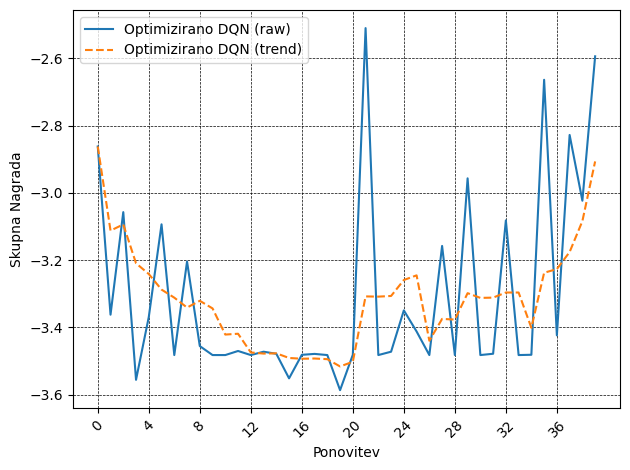

Zadnja raw nagrada: -2.59
Zadnja trend nagrada: -2.91


In [50]:
Y = [nagrada_seznam, nagrada_trend]
X = range(len(nagrada_seznam))
X_label = 'Ponovitev'
Y_label = 'Skupna Nagrada'
Legenda = ['Optimizirano DQN (raw)', 'Optimizirano DQN (trend)']
Naslov = 'Optimizacija preko 10 ponovitev DQN 2L 64 32N PC nagrada'
plotMultiY(X, Y, X_label, [Y_label], Legenda, Naslov, save_pdf=False)
print(f'Zadnja raw nagrada: {nagrada_seznam[-1]:.2f}')
print(f'Zadnja trend nagrada: {nagrada_trend[-1]:.2f}')

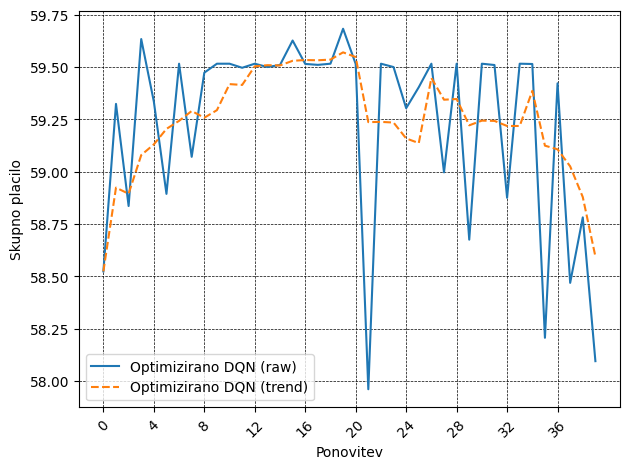

Zadnje raw placilo: 58.09
Zadnje trend placilo: 58.59


In [51]:
Y = [placilo_seznam, placilo_trend]
X = range(len(placilo_seznam))
X_label = 'Ponovitev'
Y_label = 'Skupno placilo'
Legenda = ['Optimizirano DQN (raw)', 'Optimizirano DQN (trend)']
Naslov = 'Optimizacija preko 10 ponovitev DQN 2L 64 32N PC placilo'
plotMultiY(X, Y, X_label, [Y_label], Legenda, Naslov, save_pdf=False)
print(f'Zadnje raw placilo: {placilo_seznam[-1]:.2f}')
print(f'Zadnje trend placilo: {placilo_trend[-1]:.2f}')

In [52]:
print(f'Nagrada po optimizaciji {nagradaDQN[-1]}')
print(f'Cena po optimizaciji {placiloDQN[-1]}')

Nagrada po optimizaciji -210.12219312762505
Cena po optimizaciji 3159.656564948947


#### Grafi DQN

##### Grafi DQN setup

###### MILP
Bencmark using perfect predictions.

The teoretical optimum that can be reached by other algorithms


In [53]:
env = build_dqn_env(
    dataset=test_data,
    dataset_norm=test_data_norm,
    episode_length=KorakovNaDan * 7,
    reset_mode="deterministic",
    observation_mode="sliding_window",
)
def run_milp_benchmark(env):
    """
    Runs a Mixed-Integer Linear Programming optimization over a given 
    HouseholdEnvironment episode using dynamic Australian grid pricing.
    """
    print("Building MILP Model...")
    
    # 1. Setup time horizon and extract data from the environment
    T = env.episode_length
    start_idx = 0 
    
    gen = env.arr_Gen[start_idx : start_idx + T]
    con = env.arr_Con[start_idx : start_idx + T]
    smp_prices = env.arr_SMP[start_idx : start_idx + T]
    rel_price = env.arr_RelativePrice[start_idx : start_idx + T]
    
    # ASSUMPTION: The environment contains an array of UTC datetime objects for each step
    #dates = env.arr_Dates[start_idx : start_idx + T] 
    dates = env.dataset.index[start_idx : start_idx + T]
    INTERVAL_MINS = 30 # Adjust if your env uses 15-min intervals
    
    # -------------------------------------------------------------------------
    # 2. PRE-CALCULATE TARIFF RATES FOR THE SOLVER
    # -------------------------------------------------------------------------
    # The MILP needs linear coefficients. We determine these by probing the 
    # pricing function for the cost of 1 kWh (Import) and -1 kWh (Export).
    import_rates = []
    export_rates = []
    constant_costs = []
    
    for t in range(T):
        # Cost to IMPORT 1 kWh
        import_res = calculate_interval_price(
            smp_market_price_mwh=smp_prices[t],
            total_consumed_kwh=1.0, 
            utc_date=dates[t],
            interval_minutes=INTERVAL_MINS
        )
        import_rates.append(import_res["variable_price_aud"])
        constant_costs.append(import_res["constant_price_aud"])
        
        # Revenue to EXPORT 1 kWh (pass -1.0 as total_consumed_kwh)
        export_res = calculate_interval_price(
            smp_market_price_mwh=smp_prices[t],
            total_consumed_kwh=-1.0, 
            utc_date=dates[t],
            interval_minutes=INTERVAL_MINS
        )
        # We negate the result because the function returns a negative cost for 
        # standard revenue. The solver objective subtracts revenue, so it needs a positive rate.
        export_rates.append(-export_res["variable_price_aud"])

    # 3. Define the MILP Problem
    prob = pulp.LpProblem("Household_Microgrid_Optimization", pulp.LpMinimize)
    
    # 4. Define Decision Variables
    P_buy = [pulp.LpVariable(f"P_buy_{t}", lowBound=0) for t in range(T)]
    P_sell = [pulp.LpVariable(f"P_sell_{t}", lowBound=0) for t in range(T)]
    P_ch = [pulp.LpVariable(f"P_ch_{t}", lowBound=0, upBound=env.bat_max_polnjenje) for t in range(T)]
    P_dis = [pulp.LpVariable(f"P_dis_{t}", lowBound=0, upBound=env.bat_max_praznjenje) for t in range(T)]
    E = [pulp.LpVariable(f"E_{t}", lowBound=0, upBound=env.bat_kapaciteta) for t in range(T + 1)]
    
    # 5. Define Constraints
    prob += (E[0] == max(0.0, env.bat_kapaciteta / 2.0))
    
    for t in range(T):
        # Energy Balance
        prob += (gen[t] + P_buy[t] + P_dis[t] == con[t] + P_sell[t] + P_ch[t])
        # Battery Dynamics
        prob += (E[t+1] == E[t] + P_ch[t] * env.bat_ucinkovitost - P_dis[t] / env.bat_ucinkovitost)
        
    # 6. Define Objective Function
    # Objective: Minimize (Cost of Buying) - (Revenue from Selling) + (Fixed Constant Costs)
    total_economic_cost = pulp.lpSum(
        P_buy[t] * import_rates[t] - P_sell[t] * export_rates[t] + constant_costs[t]
        for t in range(T)
    )
    prob += total_economic_cost
    
    # 7. Solve the Model
    print(f"Solving over {T} steps... (This may take a moment)")
    solver = pulp.PULP_CBC_CMD(msg=False)
    prob.solve(solver)
    
    if pulp.LpStatus[prob.status] != 'Optimal':
        print(f"Warning: Solver ended with status {pulp.LpStatus[prob.status]}")
        
    # 8. Extract Results and Reconstruct RL Environment Rewards
    results = []
    cumulative_payment = 0.0
    cumulative_rl_reward = 0.0
    
    for t in range(T):
        # Extract optimized values
        buy_val = P_buy[t].varValue or 0.0
        sell_val = P_sell[t].varValue or 0.0
        ch_val = P_ch[t].varValue or 0.0
        dis_val = P_dis[t].varValue or 0.0
        e_val = E[t].varValue or 0.0
        
        # Calculate Exact Payment Using the Pricing Function
        net_kwh = buy_val - sell_val
        interval_cost_data = calculate_interval_price(
            smp_market_price_mwh=smp_prices[t],
            total_consumed_kwh=net_kwh,
            utc_date=dates[t],
            interval_minutes=INTERVAL_MINS
        )
        
        placilo_zdaj = interval_cost_data["constant_price_aud"] + interval_cost_data["variable_price_aud"]
        cumulative_payment += placilo_zdaj
        
        # Reconstruct RL Rewards
        soc_norm = e_val / env.bat_kapaciteta if env.bat_kapaciteta > 0 else 0.0
        sprememba_baterije = (ch_val * env.bat_ucinkovitost) - (dis_val / env.bat_ucinkovitost)
                
        s_for_reward = SimpleNamespace(
            Baterija_norm=soc_norm,
            CenaElRel=rel_price[t],
        )

        r_kapaciteta = env._nagrada_1(s_for_reward)
        r_sprememba = env._nagrada_2(s_for_reward, sprememba_baterije, None)
        r_placilo = env._nagrada_3(placilo_zdaj)
        total_step_reward = env._nagrada_skupno(
            s_for_reward, sprememba_baterije, placilo_zdaj, None
        )
        cumulative_rl_reward += total_step_reward
        
        # Save step data
        results.append({
            "Step": t,
            "Date": dates[t],
            "SMP_MWh": smp_prices[t],
            "Generation": gen[t],
            "Consumption": con[t],
            "Charge_kW": ch_val,
            "Discharge_kW": dis_val,
            "SOC_kWh": e_val,
            "SOC_%": soc_norm * 100,
            "Import_Rate_kWh": import_rates[t],
            "Export_Rate_kWh": export_rates[t],
            "Step_Cost": placilo_zdaj,
            "Cum_Cost": cumulative_payment,
            "Step_RL_Reward": total_step_reward,
            "Cum_RL_Reward": cumulative_rl_reward
        })

    df_results = pd.DataFrame(results)
    
    print("\n--- MILP Optimization Complete ---")
    print(f"Total Electricity Cost (Inc GST & Fixed): ${cumulative_payment:.4f}")
    print(f"Total RL Equivalent Reward: {cumulative_rl_reward:.4f}")
    
    return df_results

###### Brez baterije, brez panelov, SARSA?
The rest of setup


In [54]:
sarsa_train_env = build_dqn_env(
    dataset=train_data,
    dataset_norm=train_data_norm,
    episode_length=len(train_data) - 1,
    reset_mode="deterministic",
    observation_mode="compact",
)

sarsa_test_env = build_dqn_env(
    dataset=test_data,
    dataset_norm=test_data_norm,
    episode_length=len(test_data) - 1,
    reset_mode="deterministic",
    observation_mode="compact",
)

In [55]:
agent_train = LinearFunctionSarsaAgent(sarsa_train_env)
agent_test = LinearFunctionSarsaAgent(sarsa_test_env)

theta_trening, agent_train = QL_trening_krajsi(agent_train, env=sarsa_train_env)
agent_test.train(1, theta_trening, 0, 0, 0, env=sarsa_test_env)
print(f'cena po optimizaciji {agent_test.Price[-1]}')

nakljucni_agent = LinearFunctionSarsaAgent(sarsa_test_env)
nakljucni_agent.train(1, None, 1, 0, 0, env=sarsa_test_env)
alternating_agent = LinearFunctionSarsaAgent(sarsa_test_env)
alternating_agent.train(1, None, 1, 0, 0, env=sarsa_test_env, alternating_actions=True)

epsilon_end_old = epsilon_end
epsilon_end = 1
nakljucni_nagradaDQN, nakljucni_placiloDQN, nakljucni_baterijaDQN, nakljucni_NagradaKapaciteta, nakljucni_NagradaSprememba, nakljucni_NagradaPlacilo = Learning_DQN(ucenje=False, random=True)
epsilon_end = epsilon_end_old

cena po optimizaciji 3381.220831763846
Random eval: epsilon = 1.0
Episode: 1
Steps per episode: 17535
Epsilon 1.0000
Final price: 4715.46 EUR


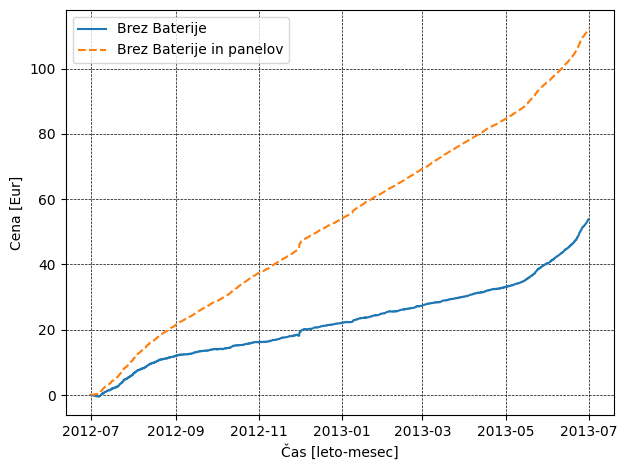

Placilo brez panelov 112.31730505065023
Placilo brez baterije 53.84942540155


In [56]:
cena = test_data["SMP"]
proizvodnja = test_data["Energy_Generation"]
poraba = test_data["Energy_Consumption"]
Placilo_brez_baterije_trenutno = 0
Placilo_brez_baterije_skupno = []
Placilo_brez_panelov_trenutno = 0
Placilo_brez_panelov_skupno = []
for i in range(len(test_data)):
    KupljenaElektrika = poraba.iloc[i] - proizvodnja.iloc[i]
    if KupljenaElektrika > 0:
        PlaciloZdaj =  cena.iloc[i]*KupljenaElektrika
    else:
        PlaciloZdaj =  cena.iloc[i]*KupljenaElektrika*faktor_cenitve     #predvidevamo da je cena prodane elektrike za foaktor cenitve nižja od cene kupljene elektrike
    Placilo_brez_baterije_trenutno += PlaciloZdaj
    Placilo_brez_baterije_skupno.append(Placilo_brez_baterije_trenutno)
    Placilo_brez_panelov_trenutno +=  poraba.iloc[i]*cena.iloc[i]
    Placilo_brez_panelov_skupno.append(Placilo_brez_panelov_trenutno)
#Placilo_brez_baterije_koncno = np.dot(poraba,cena) - np.dot(proizvodnja,cena)/4
#plt.plot(np.arange(len(poraba)),Placilo_brez_baterije_skupno)
#plt.plot(np.arange(len(poraba)),Placilo_brez_panelov_skupno)
Y = [Placilo_brez_baterije_skupno, Placilo_brez_panelov_skupno]
X = alternating_agent.Date
X_label = 'Čas [leto-mesec]'
Y_label = 'Cena [Eur]'
Legenda = ['Brez Baterije', 'Brez Baterije in panelov']
Naslov = 'Vpliv panelov na ceno elektrike pri odkupu po polovični ceni'
plotMultiY(X, Y, X_label, [Y_label],Legenda ,Naslov, save_pdf=False)
print(f"Placilo brez panelov {Placilo_brez_panelov_skupno[-1]}")
print(f"Placilo brez baterije {Placilo_brez_baterije_skupno[-1]}")

In [57]:
sarsa_no_battery_env = HouseholdEnvironment(
    dataset=test_data,
    dataset_norm=test_data_norm,
    observation_mode="compact",
    reset_mode="deterministic",
    episode_length=len(test_data) - 1,
    korakov_na_dan=KorakovNaDan,
    bat_kapaciteta=0,
    bat_ucinkovitost=BatUcinkovitost,
    bat_max_polnjenje=BatMaxPolnjenje,
    bat_max_praznjenje=BatMaxPraznjenje,
    faktor_cenitve=faktor_cenitve,
    faktor_n1=faktorN1,
    faktor_n2=faktorN2,
    faktor_n3=faktorN3,
 )

agent_brez_baterije = LinearFunctionSarsaAgent(sarsa_no_battery_env)
agent_brez_baterije.train(1, None, 1, 0, 0, env=sarsa_no_battery_env)

array([0., 0., 0., ..., 0., 0., 0.], shape=(40000,))

##### Grafi DQN analiza poskusa

In [58]:
save_pdf = False
save_png = False
print(f'BatUcinkovitost: {BatUcinkovitost}')
print(f'faktor_cenitve: {faktor_cenitve}')
print(f'BatKapaciteta: {BatKapaciteta}')
print(f'faktorN1: {faktorN1}')
print(f'faktorN2: {faktorN2}')
print(f'faktorN3: {faktorN3}')
print(f'faktor_cenitve: {faktor_cenitve}')
print(f'Nagrada po optimizaciji {nagradaDQN[-1]}')
print(f'Cena po optimizaciji DQN {placiloDQN[-1]}')
print(f'gamma: {gamma} ')
print(f'lr: {lr} ')
print(f'epsilon_start: {epsilon_start} ')
print(f'epsilon_end: {epsilon_end} ')
print(f'epsilon_decay: {epsilon_decay} ')
print(f'batch_size: {batch_size} ')
print(f'fc1_dims: {fc1_dims} ')
print(f'fc2_dims: {fc2_dims} ')
print(f'fc3_dims: {fc3_dims} ')
print(f'replace_target: {replace_target} ')
print(f'weight_decay: {weight_decay} ')

BatUcinkovitost: 0.95
faktor_cenitve: 0.6666666666666666
BatKapaciteta: 20
faktorN1: 0
faktorN2: 0
faktorN3: 1
faktor_cenitve: 0.6666666666666666
Nagrada po optimizaciji -210.12219312762505
Cena po optimizaciji DQN 3159.656564948947
gamma: 0.99 
lr: 0.001 
epsilon_start: 1.0 
epsilon_end: 0.01 
epsilon_decay: 4e-05 
batch_size: 48 
fc1_dims: 64 
fc2_dims: 32 
fc3_dims: 16 
replace_target: 336 
weight_decay: 0.0001 


Building MILP Model...
Solving over 336 steps... (This may take a moment)

--- MILP Optimization Complete ---
Total Electricity Cost (Inc GST & Fixed): $13.5235
Total RL Equivalent Reward: -8.4522


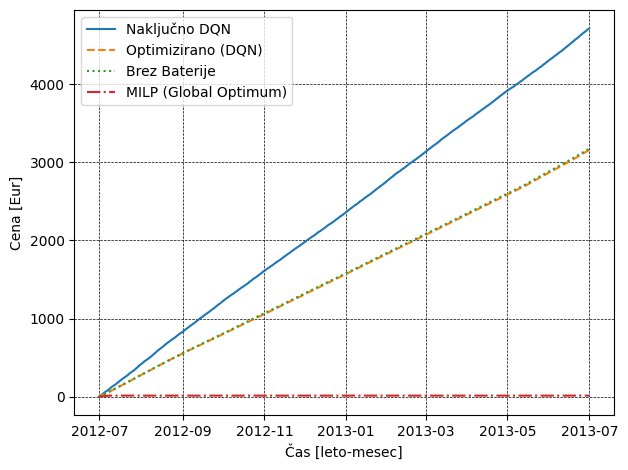

Placilo po optimizaciji (DQN): 3159.656564948947
Placilo brez baterije: 3176.69237615355
Placilo z MILP (Teoretični Optimum): 13.523531133999938


In [59]:
# --- STEP 1: Run the MILP benchmark on your environment ---
# (Make sure to run the run_milp_benchmark function provided earlier first)
df_milp = run_milp_benchmark(env)

# --- STEP 2: Update the Plotting Variables ---
# Append the cumulative cost array from the MILP DataFrame to your list of Y values.
# We slice it using [:-1] to match the length of your other tracking variables.
Y = [
    nakljucni_placiloDQN[:-1], 
    placiloDQN[:-1], 
    agent_brez_baterije.Price[:-1],
    df_milp["Cum_Cost"].to_numpy()[:-1].tolist()  # Added MILP Cumulative Cost as mutable list
]

X = nakljucni_agent.Date
X_label = 'Čas [leto-mesec]'
Y_label = 'Cena [Eur]'

# Update the legend to include MILP so the colors match correctly
Legenda = ['Naključno DQN', 'Optimizirano (DQN)', 'Brez Baterije', 'MILP (Global Optimum)'] 

Naslov = 'Cena elektrike v drugi polovici podatkov DQN vs MILP'

# --- STEP 3: Plot the multi-line chart ---
plotMultiY(X, Y, X_label, [Y_label], Legenda, Naslov, save_pdf=save_pdf, save=save_png)

# --- STEP 4: Print the final financial comparison metrics ---
print(f'Placilo po optimizaciji (DQN): {placiloDQN[-1]}')
print(f'Placilo brez baterije: {agent_brez_baterije.Price[-1]}')
print(f'Placilo z MILP (Teoretični Optimum): {df_milp["Cum_Cost"].iloc[-1]}')

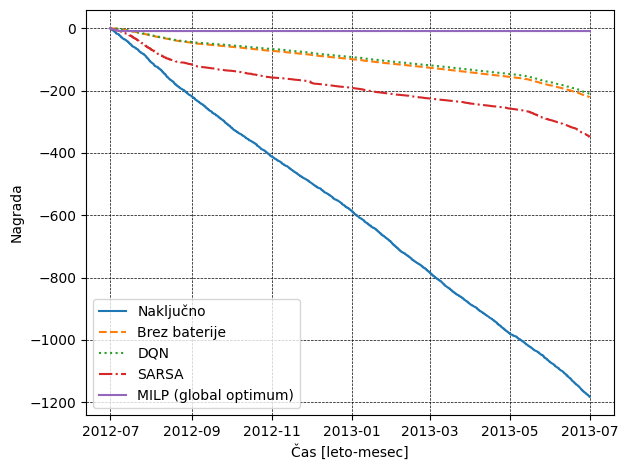

-348.5998598869383


In [60]:
### CELL 65: Primerjava skupne nagrade po različnih metodah

#plt.plot(range(len(agent_test.NagradaSkupno)),  nakljucni_agent.NagradaSkupno, 'r')
#plt.plot(range(len(agent_test.NagradaSkupno)), agent_test.NagradaSkupno, 'b')
# nakljucni_agent_NagradaSkupno = np.array(nakljucni_agent.NagradaSkupno)/1
alternating_agent_NagradaSkupno = np.array(alternating_agent.NagradaSkupno)/1
Y = [nakljucni_nagradaDQN,agent_brez_baterije.NagradaSkupno, nagradaDQN, agent_test.NagradaSkupno, df_milp["Cum_RL_Reward"].to_numpy()]
X = nakljucni_agent.Date
X_label = 'Čas [leto-mesec]'
Y_label = 'Nagrada'
Legenda = ['Naključno', 'Brez baterije', 'DQN', 'SARSA', 'MILP (global optimum)']
Naslov = 'Primerjava nagrad SARSA in DQN'
plotMultiY(X, Y, X_label, [Y_label],Legenda ,Naslov, save_pdf = save_pdf, save = save_png)
print(agent_test.NagradaSkupno[-1])

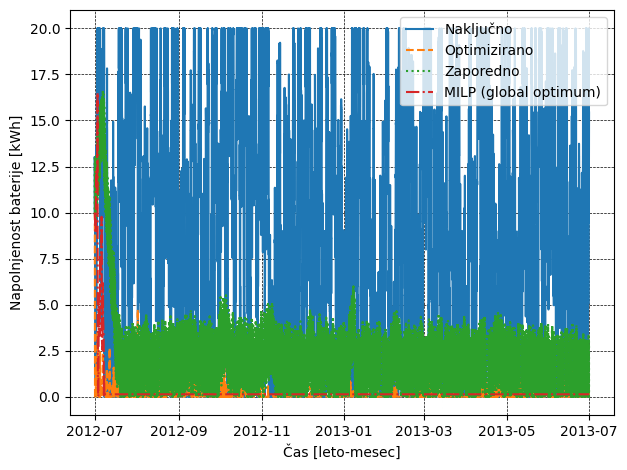

In [61]:
### CELL 62: Primerjava stanja baterije
Y = [nakljucni_agent.NapolnjenostBaterije, baterijaDQN, alternating_agent.NapolnjenostBaterije, df_milp["SOC_kWh"].to_numpy()]
X = alternating_agent.Date
X_label = 'Čas [leto-mesec]'
Y_label = 'Napolnjenost baterije [kWh]'
Legenda = ['Naključno','Optimizirano','Zaporedno', 'MILP (global optimum)']
Naslov = 'Napolnjenost baterije sistem Q spodbujevalnega učenja DQN'
plotMultiY(X, Y, X_label, [Y_label],Legenda ,Naslov, save_pdf = save_pdf, save = save_png)
# plotMultiY(X, Y, X_label, [Y_label],Legenda ,Naslov, save_pdf = True)

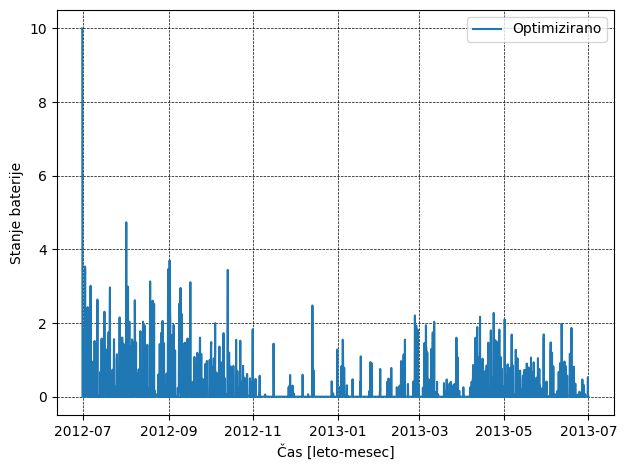

In [62]:
### CELL 64: Ogled stanja baterije
Y = [baterijaDQN]
X = alternating_agent.Date
X_label = 'Čas [leto-mesec]'
Y_label = 'Stanje baterije'
Legenda = ['Optimizirano']
Naslov = 'Proporcionalna napolnjenost baterije optimizirano DQN'
plotMultiY(X, Y, X_label, [Y_label],Legenda ,Naslov, save_pdf = save_pdf, save = save_png)

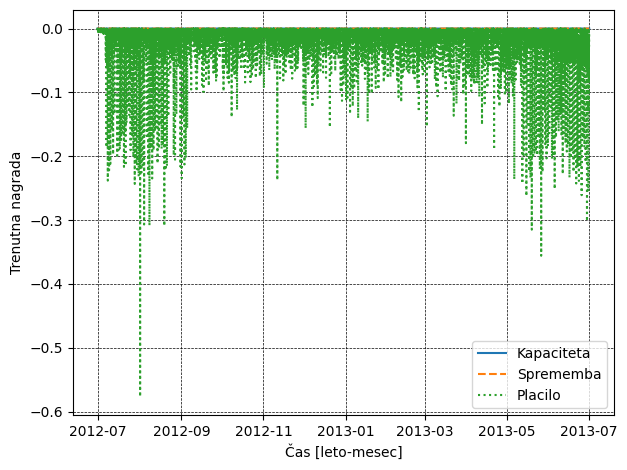

In [63]:
### CELL 63: Primerjava različnih komponent nagrade
Y = [NagradaKapaciteta, NagradaSprememba, NagradaPlacilo]
X = alternating_agent.Date
X_label = 'Čas [leto-mesec]'
Y_label = 'Trenutna nagrada'
Legenda = ['Kapaciteta','Sprememba','Placilo']
Naslov = 'Velikosti nagrad v danem trenutku 1L 16N P'
# plotMultiY(X, Y, X_label, [Y_label],Legenda ,Naslov, save_pdf = False)
plotMultiY(X, Y, X_label, [Y_label],Legenda ,Naslov, save_pdf = save_pdf, save = save_png)